In [7]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'legend.fontsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14
})

# ----------------------------
# Data
# ----------------------------
X = np.array([
    -1.0, -0.9, -0.8, -0.7, -0.6, -0.5, -0.4, -0.3, -0.2, -0.1,
     0.0,  0.1,  0.2,  0.3,  0.4,  0.5,  0.6,  0.7,  0.8,  0.9,  1.0
], dtype=float)

Y = np.array([
    -0.96, -0.577, -0.073,  0.377,  0.641,  0.66,   0.461,  0.134,
    -0.201, -0.434, -0.5,   -0.393, -0.165,  0.099,  0.307,  0.396,
     0.345,  0.182, -0.031, -0.219, -0.321
], dtype=float)


def model(theta, x):
    x0, x1, x2, x3, x4 = theta
    return x0 + x1*np.sin(x2*x) + x3*np.cos(x4*x)

def cost(theta, x, y):
    r = model(theta, x) - y
    return 0.5 * np.dot(r, r)

def grad(theta, x, y):
    x0, x1, x2, x3, x4 = theta
    r = model(theta, x) - y

    df_dx0 = np.ones_like(x)
    df_dx1 = np.sin(x2 * x)
    df_dx2 = x1 * np.cos(x2 * x) * x
    df_dx3 = np.cos(x4 * x)
    df_dx4 = -x3 * np.sin(x4 * x) * x

    g0 = np.dot(r, df_dx0)
    g1 = np.dot(r, df_dx1)
    g2 = np.dot(r, df_dx2)
    g3 = np.dot(r, df_dx3)
    g4 = np.dot(r, df_dx4)

    return np.array([g0, g1, g2, g3, g4], dtype=float)

# Backtracking line search
def backtracking_line_search(theta, d, g, x, y, alpha0=1.0, rho=0.5, c=1e-4):
    alpha = alpha0
    f0 = cost(theta, x, y)

    while cost(theta + alpha*d, x, y) > f0 + c * alpha * np.dot(g, d):
        alpha *= rho
        if alpha < 1e-12:
            break

    return alpha

# Nonlinear Conjugate Gradient

def nonlinear_cg(theta0, x, y, max_iter=5000, tol=1e-10):
    theta = theta0.astype(float).copy()

    g = grad(theta, x, y)
    d = -g

    costs = [cost(theta, x, y)]
    path = [theta.copy()]

    n = len(theta)

    for k in range(max_iter):
        if np.linalg.norm(g) < tol:
            break

        alpha = backtracking_line_search(theta, d, g, x, y)
        theta_new = theta + alpha * d
        g_new = grad(theta_new, x, y)

        # Polak-Ribiere+
        beta_num = np.dot(g_new, g_new - g)
        beta_den = np.dot(g, g) + 1e-16
        beta = max(0.0, beta_num / beta_den)

        # restart every n steps
        if (k + 1) % n == 0:
            beta = 0.0

        d = -g_new + beta * d

        # safeguard: ensure descent direction
        if np.dot(g_new, d) >= 0:
            d = -g_new

        theta = theta_new
        g = g_new

        path.append(theta.copy())
        costs.append(cost(theta, x, y))

        if abs(costs[-1] - costs[-2]) < 1e-12:
            break

    return theta, np.array(path), costs


# Multi-start
initial_guesses = [
    np.array([0.0, 1.0, 1.0, 1.0, 1.0]),
    np.array([0.0, 1.0, 2.0, 1.0, 2.0]),
    np.array([0.0, 1.0, 3.0, 1.0, 3.0]),
    np.array([0.0, 0.8, 4.0, 0.5, 2.0]),
    np.array([0.0, 0.5, 5.0, 0.5, 4.0]),
    np.array([0.0, -1.0, 2.0, 1.0, 3.0]),
]

best_theta = None
best_cost = np.inf
best_costs = None
best_path = None

for theta0 in initial_guesses:
    theta_opt, path, costs = nonlinear_cg(theta0, X, Y)
    final_cost = costs[-1]

    if final_cost < best_cost:
        best_cost = final_cost
        best_theta = theta_opt
        best_costs = costs
        best_path = path

print("Optimization problem:")
print("min 0.5 * sum_i (x0 + x1 sin(x2 Xi) + x3 cos(x4 Xi) - Yi)^2")
print("Type: unconstrained nonlinear least-squares (nonconvex)\n")

print("Method used: Nonlinear Conjugate Gradient\n")

print("Best fitted parameters:")
print(f"x0 = {best_theta[0]:.6f}")
print(f"x1 = {best_theta[1]:.6f}")
print(f"x2 = {best_theta[2]:.6f}")
print(f"x3 = {best_theta[3]:.6f}")
print(f"x4 = {best_theta[4]:.6f}")

print(f"\nFinal cost = {best_cost:.8f}")
print(f"Iterations = {len(best_costs)-1}")

Optimization problem:
min 0.5 * sum_i (x0 + x1 sin(x2 Xi) + x3 cos(x4 Xi) - Yi)^2
Type: unconstrained nonlinear least-squares (nonconvex)

Method used: Nonlinear Conjugate Gradient

Best fitted parameters:
x0 = -0.008028
x1 = -0.137836
x2 = 4.288971
x3 = -0.556965
x4 = 6.036559

Final cost = 0.11190579
Iterations = 84


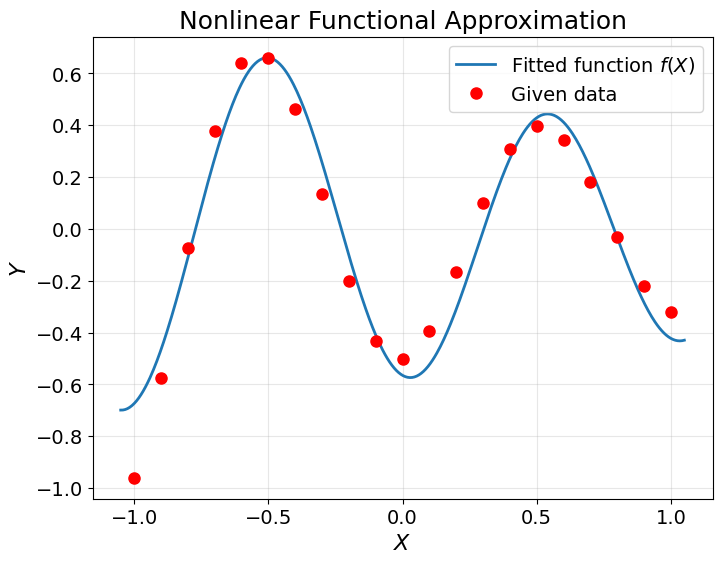

In [8]:
x_plot = np.linspace(-1.05, 1.05, 500)
y_plot = model(best_theta, x_plot)

plt.figure(figsize=(8, 6))
plt.plot(x_plot, y_plot, linewidth=2, label='Fitted function $f(X)$')
plt.plot(X, Y, 'ro', markersize=8, label='Given data')
plt.xlabel("$X$")
plt.ylabel("$Y$")
plt.title("Nonlinear Functional Approximation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

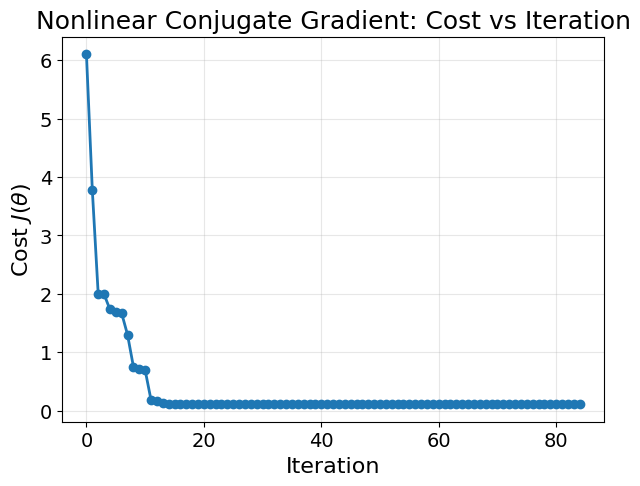

In [9]:
plt.figure(figsize=(7, 5))
plt.plot(range(len(best_costs)), best_costs, marker='o', linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Cost $J(\\theta)$")
plt.title("Nonlinear Conjugate Gradient: Cost vs Iteration")
plt.grid(True, alpha=0.3)
plt.show()